# EDA - Exploratory Data Analysis 

In [1]:
# Libraries
import os
os.environ.setdefault("MNE_3D_BACKEND", "notebook")

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data management
from pathlib import Path
import random

# Visualization
import ipywidgets as widgets
from IPython.display import display
import pprint

## TUH EEG Corpus Structure

```text
tuh_eeg/
│
├── tuh_eeg/                         # TUEG - General EEG Corpus
│   └── v2.0.2/
│       ├── AAREADME.txt
│       ├── DOCS/
│       │   └── *.list
│       └── edf/
│           └── <group_patient_id>/
│               └── <patient_id>/
│                   └── <session_id>/
│                       └── <montage_id>/
│                           └── *.edf
│
├── tuh_eeg_artifact/                # TUAR - Artifact Corpus
│   └── v3.0.1/
│       ├── AAREADME.txt
│       ├── DOCS/
│       └── edf/
│           └── <montage_id>/
│               ├── *.edf
│               └── *.csv
│
├── tuh_eeg_epilepsy/                # TUEP - Epilepsy Corpus
│   └── v3.0.1/
│       ├── AAREADME.txt
│       ├── DOCS/
│       │   └── metadata_v00.xlsx
│       └── <epilepsy_confirmation>/
│           └── <patient_id>/
│               └── <session_id>/
│                   └── <montage_id>/
│                       ├── *.edf
│                       └── *.csv
│
├── tuh_eeg_events/                  # TUEV - Event Corpus
│   └── v2.0.1/
│       ├── AAREADME.txt
│       └── edf/
│           ├── train/
│           └── eval/
│               └── <patient_id>/
│                   ├── *.edf
│                   ├── *.red
│                   ├── *.htk
│                   └── *.lab
│
└── tuh_eeg_seizure/                 # TUSZ - Seizure Corpus
    └── v2.0.6/
        ├── AAREADME.md
        ├── DOCS/
        │   ├── metadata_v06.xlsx
        │   └── seizure_types_v02.xlsx
        └── edf/
            ├── train/
            ├── dev/
            └── eval/
                └── <patient_id>/
                    └── <session_id>/
                        └── <montage_id>/
                            ├── *.edf
                            └── *.csv
```
  
### Referencing methods and channel selection
- AR: Average Reference
- LE: Linked Ear reference
- With and without references

In [2]:
# Path of the TUH EEG Corpus
base_path = Path(r"F:\MAFER\UVG\TRABAJO DE GRADUACIÓN MECATRÓNICA\TUH_EEG")

# TUH Corpus structure
CORPUS_PATHS = {
    "all_corpus":   Path("tuh_eeg")/"v2.0.2",
    "artifact":     Path("tuh_eeg_artifact")/"v3.0.1",
    "epilepsy":     Path("tuh_eeg_epilepsy")/"v3.1.0",
    "seizure":     Path("tuh_eeg_seizure")/"v2.0.6",
    "events":     Path("tuh_eeg_events")/"v2.0.1",
}

# Pandas table display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 20)
pd.set_option("display.width", 1000)

In [3]:
# Corpus - pacients
def get_sessions(base_path, corpus_name):
    """
    Returns a list of sessions according to the specified corpus.
    """
    corpus_path = base_path / CORPUS_PATHS[corpus_name] / Path("DOCS")
    registers = []
    for session in corpus_path.rglob("*.list"):
        with open(session, "r") as f:
            session_lines = f.readlines()
            session_lines = [line.strip() for line in session_lines if not line.startswith("#")]
            for line in session_lines:
                if "/" in line:
                    pacient, session_id = line.split("/")
                    registers.append({
                        "Corpus": corpus_name,
                        "Patient": pacient,
                        "Session": session_id,
                        "Source File": session.name,
                        "Session Year": line.split("_")[1],
                        "List Type": session.stem,
                        "Session ID": f"{pacient}/{session_id}"
                    })

    return pd.DataFrame(registers)

# Data recopilation
sessions_df = get_sessions(base_path, "all_corpus")



>> Sessions database preview


,Corpus,Patient,Session,Source File,Session Year,List Type,Session ID
0,all_corpus,aaaaarvn,s001_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarvn/s001_2014
1,all_corpus,aaaaarwk,s002_2016,sessions_tueg.list,2016,sessions_tueg,aaaaarwk/s002_2016
2,all_corpus,aaaaarwk,s001_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarwk/s001_2014
3,all_corpus,aaaaarvt,s001_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarvt/s001_2014
4,all_corpus,aaaaarud,s001_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarud/s001_2014
5,all_corpus,aaaaarvj,s001_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarvj/s001_2014
6,all_corpus,aaaaarum,s001_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarum/s001_2014
7,all_corpus,aaaaarum,s002_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarum/s002_2014
8,all_corpus,aaaaarvd,s009_2015,sessions_tueg.list,2015,sessions_tueg,aaaaarvd/s009_2015
9,all_corpus,aaaaarvd,s002_2014,sessions_tueg.list,2014,sessions_tueg,aaaaarvd/s002_2014



>> Patients per corpus


List Type
sessions_tueg                              14987
sessions_tueg_common_with_tuep               200
sessions_tueg_common_with_tusz               675
sessions_tueg_common_with_tusz_and_tuep      855
sessions_tueg_uniq                         14530
sessions_tuep                                200
sessions_tusz                                675
Name: Patient, dtype: int64


>> Sessions per corpus


List Type
sessions_tueg                              26846
sessions_tueg_common_with_tuep               698
sessions_tueg_common_with_tusz              1643
sessions_tueg_common_with_tusz_and_tuep     2228
sessions_tueg_uniq                         24618
sessions_tuep                                698
sessions_tusz                               1643
Name: Session ID, dtype: int64


>> Sessions per patient per corpus


,n_sessions
count,14987.000000
mean,1.791286
std,2.051830
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,46.000000


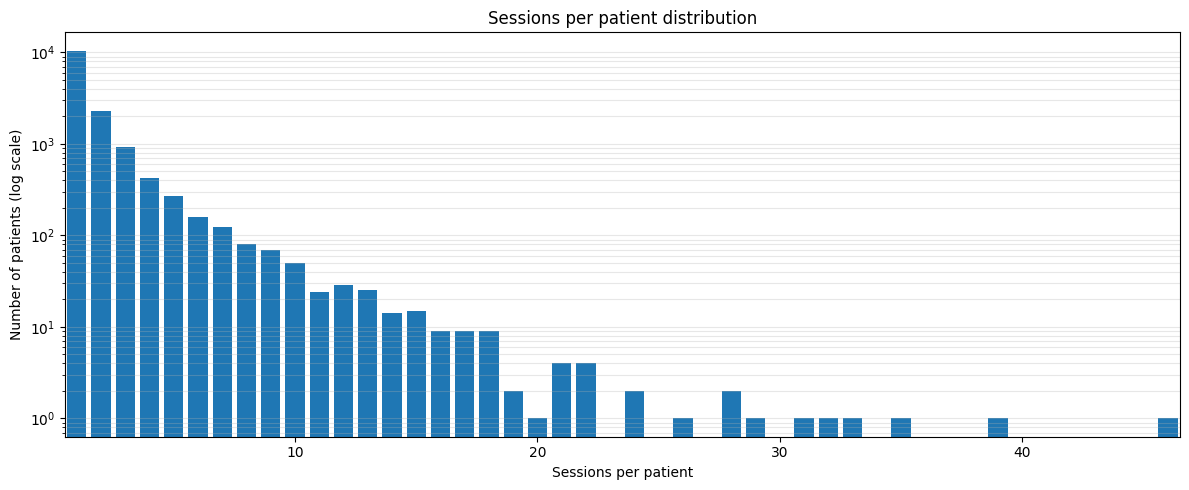

In [4]:
# TUH EEG Data Analysis -----------------------------------------------------------------------------------
# Preview of database
print("\n>> Sessions database preview")
display(sessions_df.head(10))

# Patients per corpus
print("\n>> Patients per corpus")
display(sessions_df.groupby("List Type")["Patient"].nunique())

# Sessions per corpus
print("\n>> Sessions per corpus")
display(sessions_df.groupby("List Type")["Session ID"].nunique())

# Sessions per patient per corpus
print("\n>> Sessions per patient per corpus")
sessions_per_patient = sessions_df.groupby("Patient")["Session ID"].nunique().sort_values(ascending=False)
sessions_per_patient_df = sessions_per_patient.to_frame(name="n_sessions")

display(sessions_per_patient_df.describe())

# Count how many patients have each number of sessions
counts = sessions_per_patient.value_counts().sort_index()

# x-axis: number of sessions
# y-axis: number of patients
plt.figure(figsize=(12, 5))
plt.bar(counts.index.astype(int), counts.to_numpy(dtype=int))

plt.yscale("log")
plt.xlabel("Sessions per patient")
plt.ylabel("Number of patients (log scale)")
plt.title("Sessions per patient distribution")
plt.grid(axis="y", which="both", alpha=0.3)
plt.xlim(0.5, max(counts.index.astype(int)) + 0.5)
plt.tight_layout()
plt.show()

# Optional export to CSV for full inspection outside Jupyter
export = False  # Change to True if you want to export the summary to CSV
if export:
    output_csv = "sessions_per_patient.csv"
    sessions_per_patient_df.to_csv(output_csv)
    print(f"\nExported summary to: {output_csv}")

```text
(5) Total duration: 97,467,928 secs (27,074.4238 hours)
    total num files processed successfully was 70831 out of 70831
    total dur of data processed = 97226774.0000 secs | 1620446.2333 mins | 27007.4372 hrs
    avg file dur = 1372.6585 secs | 22.8776 mins | 0.3813 hrs

(6) Signal Data:
    over 40 different channel configurations
    sample frequency varies from 250 Hz to 1024 Hz
    95% of the data includes a 10/20 configuration
    as a subset of the available channels

(7) Size of the corpus (the edf subdirectory): 1,643 Gbytes
    nedc_130_[1]: du -sBG edf
    1643G	edf
```

## Signal analysis

In [ ]:
# Corpus signal data
def get_edf_data(base_path, corpus_name):
    """
    Returns all signal parameters of a specific corpus.
    """
    corpus_path = base_path / CORPUS_PATHS[corpus_name]
    montages = [
        "01_tcp_ar", "02_tcp_le", "03_tcp_ar_a", "04_tcp_le_a",
        "05_tcp_ar_b", "06_tcp_le_b", "07_tcp_ar_c", "08_tcp_le_c"
    ]

    registers = []

    for session in corpus_path.rglob("*.edf"):
        montage = session.parent.name if session.parent.name in montages else None
        document_name = Path(session.name).stem
        session_id = next((part for part in document_name.split("_") if part.startswith("s") and part[1:].isdigit()), None)
        pacient = next((part for part in document_name.split("_") if len(part) == 8 and part.isalpha()), None)
        session_section = next((part for part in document_name.split("_") if part.startswith("t") and part[1:].isdigit()), None)

        mne.set_log_level("WARNING")
        edf_data = mne.io.read_raw_edf(session, preload=False, verbose="WARNING")

        registers.append({
            "Corpus": corpus_name,
            "Montage": montage,
            "Session": session_id,
            "Patient": pacient,
            "Section": session_section,
            "Channels": edf_data.ch_names,
            "Amount of channels": len(edf_data.ch_names),
            "Sampling frequency [Hz]": edf_data.info["sfreq"],
            "Duration [s]": edf_data.times[-1] if len(edf_data.times) > 0 else np.nan,
            "Total amount of sampling data": edf_data.n_times,
        })

    return pd.DataFrame(registers)

# EDFs Data extraction
signal_sessions_epilepsy_df = get_edf_data(base_path, "epilepsy")
signal_sessions_artifact_df = get_edf_data(base_path, "artifact")
signal_sessions_events_df = get_edf_data(base_path, "events")
signal_sessions_seizure_df = get_edf_data(base_path, "seizure")
signal_sessions_all_df = pd.concat([
    signal_sessions_epilepsy_df,
    signal_sessions_artifact_df,
    signal_sessions_events_df,
    signal_sessions_seizure_df 
])

In [6]:
display(signal_sessions_all_df.head(5))

,Corpus,Montage,Session,Patient,Section,Channels,Amount of channels,Sampling frequency [Hz],Duration [s],Total amount of sampling data
0,epilepsy,02_tcp_le,s001,aaaaaanr,t001,"[EEG FP1-LE, EEG...",33,250.0,1213.996,303500
1,epilepsy,02_tcp_le,s002,aaaaaanr,t000,"[EEG FP1-LE, EEG...",41,250.0,129.996,32500
2,epilepsy,02_tcp_le,s002,aaaaaanr,t001,"[EEG FP1-LE, EEG...",41,250.0,1251.996,313000
3,epilepsy,01_tcp_ar,s003,aaaaaanr,t000,"[EEG FP1-REF, EE...",36,250.0,1324.996,331250
4,epilepsy,01_tcp_ar,s004,aaaaaanr,t000,"[EEG FP1-REF, EE...",30,250.0,1270.996,317750



>> Distribution of the sampling frequency


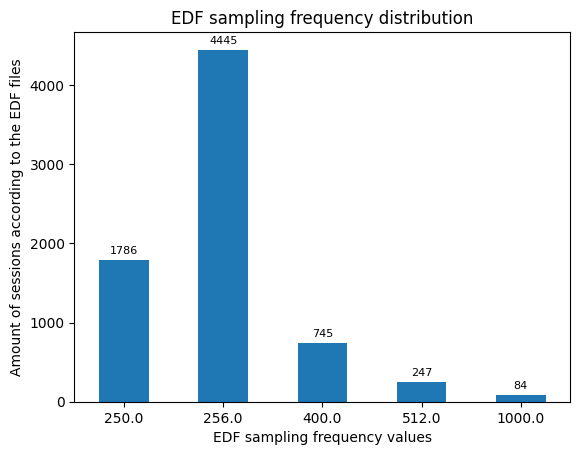


>> Distribution of the amount of channels


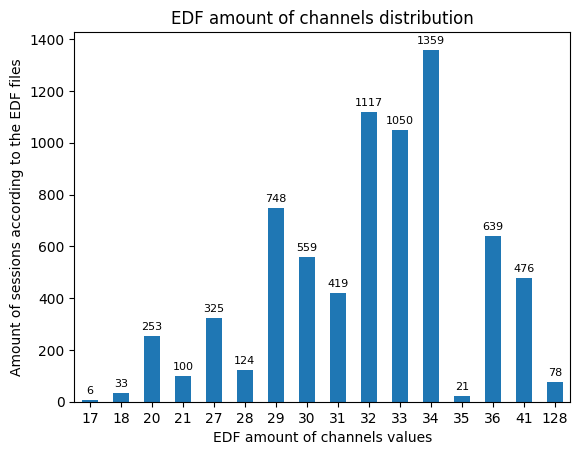


>> Channel matrix preview


Amount of channels,17,18,20,21,27,28,29,30,31,32,33,34,35,36,41,128,Total files,N variants present
Channels,,,,,,,,,,,,,,,,,,
EEG C3-REF,6,33,253,100,325,124,748,559,419,1090,815,1359,21,639,0,78,6569,15
EEG C4-REF,6,33,253,100,325,124,748,559,419,1090,815,1359,21,639,0,78,6569,15
EEG CZ-REF,6,33,253,100,325,124,748,559,419,1090,815,1359,21,639,0,78,6569,15
EEG F3-REF,6,33,253,100,325,124,748,559,419,1090,815,1359,21,639,0,78,6569,15
EEG F4-REF,6,33,253,100,325,124,748,559,419,1090,815,1359,21,639,0,78,6569,15



>> Sessions with 128 channels


,Corpus,Montage,Session,Patient,Section,Channels,Amount of channels,Sampling frequency [Hz],Duration [s],Total amount of sampling data
303,artifact,03_tcp_ar_a,s002,aaaaabnn,t001,"[EEG FP1-REF, EE...",128,400.0,353.9975,141600
304,artifact,03_tcp_ar_a,s002,aaaaabnn,t002,"[EEG FP1-REF, EE...",128,400.0,276.9975,110800
305,artifact,03_tcp_ar_a,s002,aaaaabnn,t004,"[EEG FP1-REF, EE...",128,400.0,303.9975,121600
2226,seizure,03_tcp_ar_a,s002,aaaaabjt,t000,"[EEG FP1-REF, EE...",128,400.0,364.9975,146000
2227,seizure,03_tcp_ar_a,s002,aaaaabjt,t001,"[EEG FP1-REF, EE...",128,400.0,403.9975,161600
...,...,...,...,...,...,...,...,...,...,...
2787,seizure,03_tcp_ar_a,s004,aaaaafxr,t006,"[EEG FP1-REF, EE...",128,400.0,4.9975,2000
2788,seizure,03_tcp_ar_a,s002,aaaaafye,t000,"[EEG FP1-REF, EE...",128,400.0,294.9975,118000
2789,seizure,03_tcp_ar_a,s002,aaaaafye,t001,"[EEG FP1-REF, EE...",128,400.0,294.9975,118000
2790,seizure,03_tcp_ar_a,s002,aaaaafye,t002,"[EEG FP1-REF, EE...",128,400.0,294.9975,118000


: 

In [ ]:
%matplotlib inline

## EDA Visualization
# General function to plot visualization for the given characteristic of the EDF Artifact corpus analysis
def plot_visualization(column_name, analyzed_parameter):
    """Plot visualization for the given dataframe column"""
    data = signal_sessions_all_df[column_name].value_counts().sort_index()
    axes = pd.DataFrame(data).reset_index().plot.bar(
        x=column_name,
        rot=0,
        title=f"EDF {analyzed_parameter} distribution",
        xlabel=f"EDF {analyzed_parameter} values",
        ylabel="Amount of sessions according to the EDF files",
        legend=False,
    )

    for container in axes.containers:
        axes.bar_label(container, label_type="edge", fontsize=8, padding=3)

    return axes

# Frecuency distribution of the sampling frequency
print("\n>> Distribution of the sampling frequency")
plot_visualization("Sampling frequency [Hz]", "sampling frequency")
plt.show()

# Channels distribution - examination of correct data channels
print("\n>> Distribution of the amount of channels")
plot_visualization("Amount of channels", "amount of channels")
plt.show()

# Examination of representative channels accordint to the amount found by the distribution
exploded = signal_sessions_all_df[["Amount of channels", "Channels"]].explode("Channels").sort_values(by="Amount of channels").reset_index(drop=True)
channel_matrix = pd.crosstab(exploded["Channels"], exploded["Amount of channels"])
channel_matrix["Total files"] = channel_matrix.drop(columns=[c for c in channel_matrix.columns if c == "Total files"], errors="ignore").sum(axis=1)
channel_matrix["N variants present"] = (channel_matrix.drop(columns="Total files") > 0).sum(axis=1)
channel_matrix = channel_matrix.sort_values(["N variants present", "Total files"], ascending=False)
print("\n>> Channel matrix preview")
display(channel_matrix.head(5))

# Manual analysis of sessions with 128 channels to determine the most representative channels for the corpus
print("\n>> Sessions with 128 channels")
display(signal_sessions_all_df.loc[signal_sessions_all_df["Amount of channels"] == 128])


In [6]:
# Analyze all session for a specific corpus
## TUAR
## TUEP
## 

In [ ]:
# Frecuencia de muestreo
# Duración de los archivos
# Número de canales
# Configuraciones de montaje

## Annotation analysis

In [ ]:
# Classes distribution
# Balance y desbalance de clases en los datasets para evaluar el remuestreo

## Data Quality

In [ ]:
# Check all edf and csv
# Detección de canales planos, saturados o con ruido excesivo
# Consistencia entre nombres de canales a través de sesiones/montajes

### Recomended for EDA
1. Exploración a nivel de señal

Distribución de frecuencias de muestreo (mencionas que varía de 250 Hz a 1024 Hz, pero no lo analizas cuantitativamente)
Distribución de duración de archivos (no solo sesiones por paciente, sino duración real de cada grabación)
Distribución de número de canales por archivo/montaje
Conteo real de las configuraciones de montaje (mencionas "+40 configuraciones" pero no hay un value_counts() real sobre esto en tu código — el que empezaste tiene un bug)

2. Análisis de anotaciones/etiquetas (crítico si vas a entrenar un modelo)

Distribución de clases en TUAR (tipos de artefactos)
Distribución de tipos de crisis en TUSZ (usando seizure_types_v02.xlsx)
Balance/desbalance de clases — esto es clave para decidir estrategias de muestreo o pérdida ponderada

3. Calidad de datos

Verificación de archivos corruptos o ilegibles (intenta leer todos los EDF y registra fallos)
Detección de canales planos, saturados o con ruido excesivo
Consistencia entre nombres de canales a través de sesiones/montajes

4. Metadata clínica (para TUEP especialmente)

Cruce con metadata_v00.xlsx — edad, sexo, medicación, confirmación de epilepsia
¿Hay variables demográficas que correlacionen con la señal o con las etiquetas?

5. Visualización de señal real

Graficar ejemplos de cada clase (artefacto vs. normal, crisis vs. no-crisis)
Espectro de potencia (PSD) de muestras representativas

6. Splits

Verificar que los splits train/dev/eval estén balanceados y no tengan fuga de pacientes entre conjuntos (mismo paciente en train y test es un error común)

In [ ]:
# Function to identify and group all dataset files
def dataset_index(base_path, dataset_name):
    base_path = base_path/CORPUS_PATHS[dataset_name]
    registers = []

    for edf_file in base_path.rglob("*.edf"):
        csv_file = edf_file.with_suffix(".csv")

        # Save origin of the file (montage) as the name of the parent folder
        montage = edf_file.parent.name

        if csv_file.exists():
            registers.append({
                "dataset": dataset_name,
                "montage": montage,
                "edf_path": edf_file,
                "csv_path": csv_file,
                "document": edf_file.stem 
        })

    return pd.DataFrame(registers)

# Visualization of dataset (verification of documents available)
dataset_index_df = dataset_index(base_path, "artifact")

print("Dataset Index\n", dataset_index_df.head(5))

In [ ]:
df = pd.read_csv(
    "sessions_tueg.list",
    header=None,
    names=["path"]
)

df["patient"] = df["path"].str.split("/").str[0]
df["session"] = df["path"].str.split("/").str[1]
df["year"] = df["session"].str.extract(r"(\d{4})")

print(df.head())

raw = mne.io.read_raw_edf(r"F:\MAFER\UVG\TRABAJO DE GRADUACIÓN MECATRÓNICA\DATA_EEG_TUH\tuh_eeg_artifact\v3.0.1\edf\01_tcp_ar\aaaaaaju_s005_t000.edf", preload=True)
print(raw.times[-1])          # duración en segundos
print(raw.n_times / raw.info["sfreq"])  # también da la duración
pprint.pprint(raw.__dict__)

In [ ]:
dataset_index_df["montage"].value_counts()

In [ ]:
# Sampling for starting data analysis

In [ ]:


def find_pairs_edf_csv(base_path):
    base_path = Path(base_path)
    pairs = []
    for edf_file in base_path.rglob("*.edf"):
        csv_file = edf_file.with_suffix(".csv")
        if csv_file.exists():
            pairs.append((edf_file, csv_file))
        else:
            print(f"⚠️ Not available CSV for: {edf_file.name}")
    return pairs



def load_dataset(dataset_name):
    path = CORPUS_PATHS[dataset_name]
    pairs = find_pairs_edf_csv(path)
    print(f"[{dataset_name}] {len(pairs)} pairs found")
    return pairs

pairs_path = load_dataset("artifact")
pairs_test = random.sample(pairs_path, 5)


In [ ]:
import pandas as pd
from pathlib import Path

def construir_indice(base_path, nombre_corpus):
    base_path = Path(base_path)
    registros = []

    for edf_file in base_path.rglob("*.edf"):
        csv_file = edf_file.with_suffix(".csv")

        # Extrae el nombre de la carpeta de montaje (ej. "01_tcp_ar") de la ruta
        montaje = edf_file.parent.name

        if csv_file.exists():
            registros.append({
                "corpus": nombre_corpus,
                "montaje": montaje,
                "edf_path": edf_file,
                "csv_path": csv_file,
                "archivo": edf_file.stem  # nombre sin extensión, ej. "aaaaaaju_s005_t000"
            })

    return pd.DataFrame(registros)

df_artifact = construir_indice(
    base_path / "tuh_eeg_artifact" / "v3.0.1" / "edf",
    nombre_corpus="artifact"
)

print(df_artifact.shape)
print(df_artifact['montaje'].value_counts())   # cuántos archivos hay por cada tipo de montaje
print(df_artifact['tiene_csv'].value_counts())  # confirma que todos tienen su CSV correspondiente

## Análisis de opciones de preprocesamiento

In [ ]:
# Data CHB-MIT Scalp EEG Database
edf = mne.io.read_raw_edf(r"F:\MAFER\UVG\TRABAJO DE GRADUACIÓN MECATRÓNICA\DATA_EEG_TUH\tuh_eeg_epilepsy\v2.0.1\00_epilepsy\aaaaaanr\s001_2003\02_tcp_le\aaaaaanr_s001_t001.edf", preload=True)
print(edf.info.ch_names)

In [ ]:
# Selección de canales a graficar
channel_checkboxes = [
    widgets.Checkbox(value=True, description=ch, indent=False)
    for ch in edf.info['ch_names']
]

# Acomodarlos en columnas para que no sea una lista gigante vertical
grid = widgets.GridBox(
    channel_checkboxes,
    layout=widgets.Layout(grid_template_columns="repeat(4, 200px)")
)

button = widgets.Button(description="Graficar canales seleccionados")
output = widgets.Output()

def on_button_click(b):
    selected = [cb.description for cb in channel_checkboxes if cb.value]
    with output:
        output.clear_output()
        if not selected:
            print("Selecciona al menos un canal.")
            return
        edf.plot(
            duration=10,
            n_channels=len(selected),
            order=[edf.info['ch_names'].index(ch) for ch in selected],
            picks=selected,
            scalings={'eeg': 100e-6},
            title='EEG Data - Canales visibles',
            show=True,
            block=False
        )

button.on_click(on_button_click)

display(grid, button, output)

### Preprocessing alternatives
- Notch
- Re-referenciación
- Eliminación de artefactos
- Detrending, interpolación de canales malos, epoching
- PyPREP y MNE-Python

* STFT
* Hilbert-Huang - EMD
* CSP
* ICA or PCA
* Beamforming, localización de fuentes (dSPM, sLORETA, LCMV)
* PyEEG


In [ ]:
import pandas as pd

df = pd.read_csv("C:\Users\ferch\Documents\Various\EngineeringDesignAndInnovation\Datasets\tuh_eeg_epilepsy\00_epilepsy\aaaaaamc\s012_2015\01_tcp_ar\aaaaaamc_s012_t001.cvs")
print(df.head(10))
print(df.columns)

# Pipeline definition
The pipeline requires tests to establish the appropiate preprocessing to start training ML models for feature extraction.